In [1]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:
# 1. Load data
data = pd.read_csv("../data/cover_data.csv")

data.info()
data.describe()
print(data.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null  int64
 12 

In [3]:
# 2. Split train and test data
TARGET_COL = "class"

x = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

#  Train / Val / Test split (80/10/10)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
)


In [4]:
# 3. Preprocessing
numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

x_train_processed = preprocessor.fit_transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)

In [ ]:
# 4. Model building
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_processed.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
]
)

# 5. Model compiling
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 6. Model training
history = model.fit(
    x_train_processed,
    y_train,
    validation_data=(x_val_processed, y_val),
    epochs=50,
    batch_size=32
)

# --- save training curve ---
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Model Loss")
plt.legend()
plt.savefig("../reports/training_curve.png", dpi=200, bbox_inches="tight")
plt.close()

# 7. Model evaluating
test_metrics = model.evaluate(x_test_processed, y_test)
print("Test metrics: ", dict(zip(model.metrics_names, test_metrics)))

Epoch 1/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 15s 995us/step - loss: 1.0394 - mae: 0.6243 - val_loss: 0.8146 - val_mae: 0.5372
Epoch 2/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 0.8021 - mae: 0.5473 - val_loss: 0.7025 - val_mae: 0.5048
Epoch 3/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.7177 - mae: 0.5177 - val_loss: 0.6482 - val_mae: 0.4793
Epoch 4/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.6708 - mae: 0.5004 - val_loss: 0.6081 - val_mae: 0.4715
Epoch 5/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.6402 - mae: 0.4874 - val_loss: 0.5744 - val_mae: 0.4507
Epoch 6/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 0.6187 - mae: 0.4777 - val_loss: 0.5623 - val_mae: 0.4416
Epoch 7/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.6012 - mae: 0.4707 - val_loss: 0.5318 - val_mae: 0.4351
Epoch 8/50
14526/14526 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.5869 - mae: 0.4641 - val_loss: 0.5248 - val_mae: 0.4298
Epoch 9/50
145

In [7]:
from tensorflow import keras
# 8 Save model
model.save("../models/forest_cover_model.keras")

# 9 Reconstruction model
reconstructed_model = keras.models.load_model("../models/forest_cover_model.keras")

# 10 Verify reconstruction
print(reconstructed_model.summary())

test_metrics = reconstructed_model.evaluate(x_test_processed, y_test)
print("Loaded model metrics:", test_metrics)

# Another testing method:
np.testing.assert_allclose(
    model.predict(x_test_processed), reconstructed_model.predict(x_test_processed)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,085 (180.02 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,724 (120.02 KB)

None
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 1s 464us/step - loss: 0.3931 - mae: 0.3615
Loaded model metrics: [0.3930817246437073, 0.3614646792411804]
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 1s 315us/step
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 1s 289us/step


1816/1816 ━━━━━━━━━━━━━━━━━━━━ 1s 290us/step


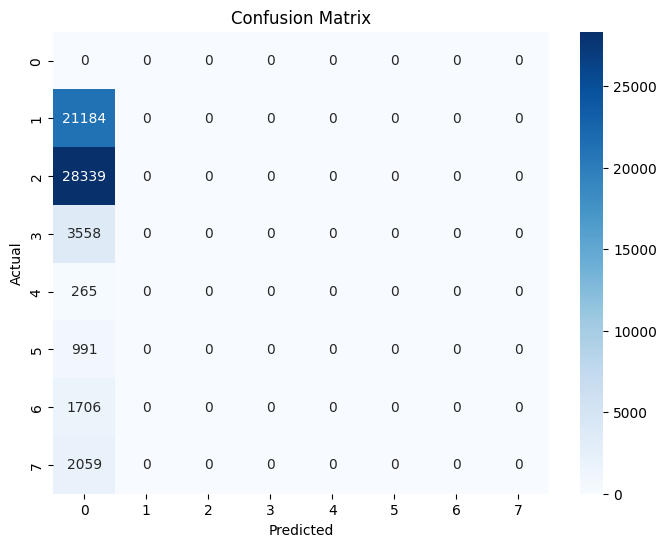

In [ ]:
# 11 Model visualization
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred_probs = model.predict(x_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("../reports/confusion_matrix.png")
plt.show()